In [34]:
import pandas as pd
import numpy as np

In [35]:
wine = pd.read_csv(r'D:\mca\sem 2\ai\lab 2\winequality-white.csv',sep=';')
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [36]:
wine.mean()

fixed acidity             6.854788
volatile acidity          0.278241
citric acid               0.334192
residual sugar            6.391415
chlorides                 0.045772
free sulfur dioxide      35.308085
total sulfur dioxide    138.360657
density                   0.994027
pH                        3.188267
sulphates                 0.489847
alcohol                  10.514267
quality                   5.877909
dtype: float64

In [37]:
wine.median()

fixed acidity             6.80000
volatile acidity          0.26000
citric acid               0.32000
residual sugar            5.20000
chlorides                 0.04300
free sulfur dioxide      34.00000
total sulfur dioxide    134.00000
density                   0.99374
pH                        3.18000
sulphates                 0.47000
alcohol                  10.40000
quality                   6.00000
dtype: float64

In [38]:
wine.std()

fixed acidity            0.843868
volatile acidity         0.100795
citric acid              0.121020
residual sugar           5.072058
chlorides                0.021848
free sulfur dioxide     17.007137
total sulfur dioxide    42.498065
density                  0.002991
pH                       0.151001
sulphates                0.114126
alcohol                  1.230621
quality                  0.885639
dtype: float64

In [39]:
wine.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

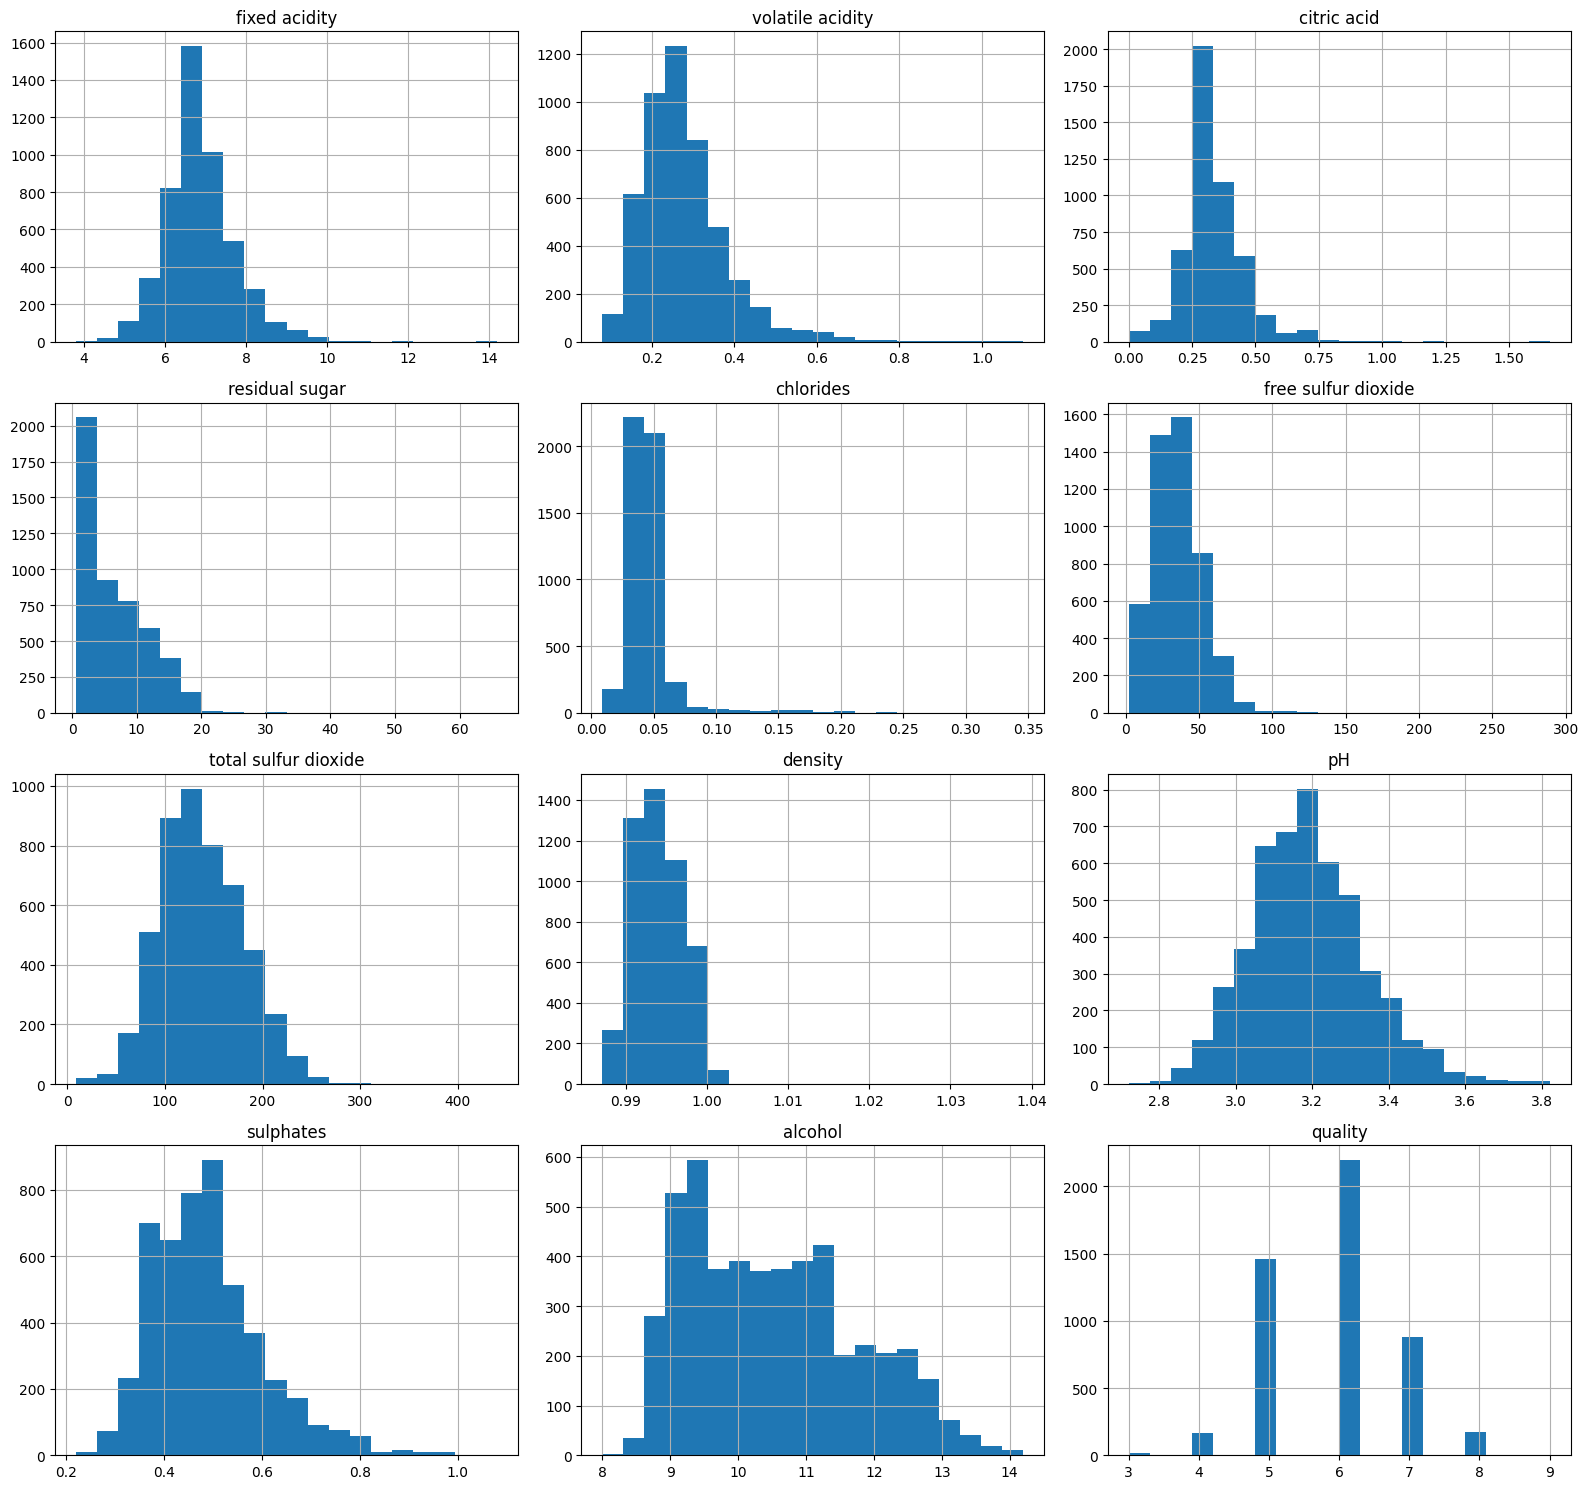

In [40]:
import matplotlib.pyplot as plt
wine.hist(bins=20,figsize=(16,15))
plt.tight_layout()
plt.show()

<Axes: >

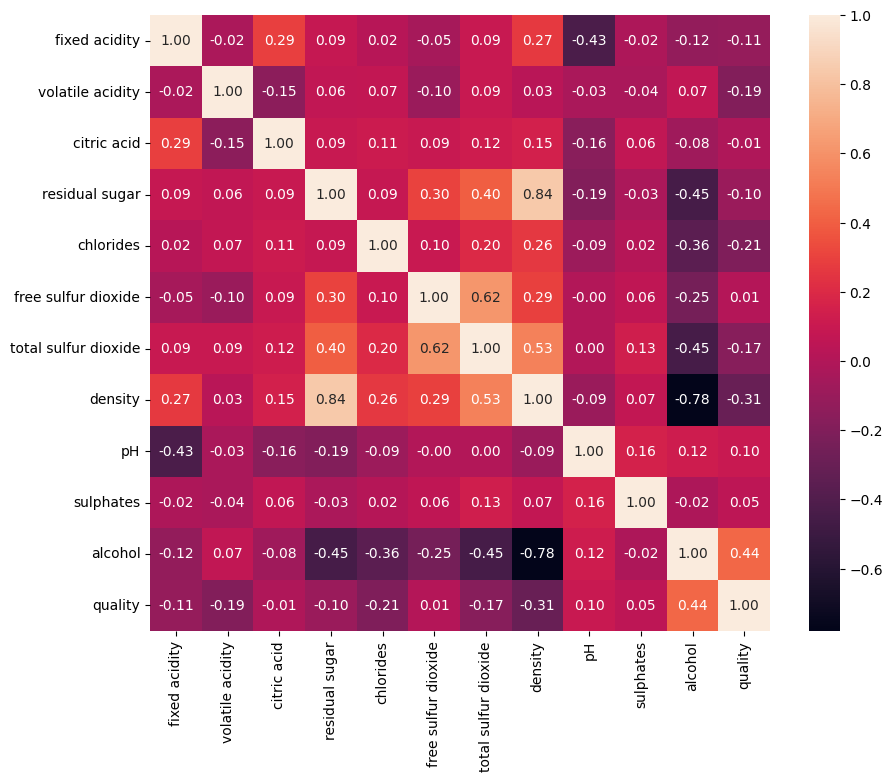

In [41]:
import seaborn as sns
corr = wine.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,fmt='.2f')

In [42]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(wine)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [43]:
wine.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [44]:
X=wine.iloc[:,:-1]
y = wine.iloc[:,-1]
X.shape,y.shape

((4898, 11), (4898,))

In [45]:
scaler.fit(X)
X = scaler.transform(X)

In [46]:
X

array([[0.30769231, 0.18627451, 0.21686747, ..., 0.25454545, 0.26744186,
        0.12903226],
       [0.24038462, 0.21568627, 0.20481928, ..., 0.52727273, 0.31395349,
        0.24193548],
       [0.41346154, 0.19607843, 0.24096386, ..., 0.49090909, 0.25581395,
        0.33870968],
       ...,
       [0.25961538, 0.15686275, 0.11445783, ..., 0.24545455, 0.27906977,
        0.22580645],
       [0.16346154, 0.20588235, 0.18072289, ..., 0.56363636, 0.18604651,
        0.77419355],
       [0.21153846, 0.12745098, 0.22891566, ..., 0.49090909, 0.11627907,
        0.61290323]], shape=(4898, 11))

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit_transform(y)


array([3, 3, 3, ..., 3, 4, 3], shape=(4898,))

In [48]:
y

0       6
1       6
2       6
3       6
4       6
       ..
4893    6
4894    5
4895    6
4896    7
4897    6
Name: quality, Length: 4898, dtype: int64

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.shape,y_train.shape

((3281, 11), (3281,))

In [50]:
y.value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

In [51]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [52]:
from tensorflow.keras.utils import to_categorical
y_test = to_categorical(y_test)
y_train = to_categorical(y_train)

In [53]:
model = Sequential()

model.add(Dense(11,activation='relu',input_dim = 11))
model.add(Dense(11,activation='relu'))
model.add(Dense(y_train.shape[1],activation='softmax'))



c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 384 (1.50 KB)

 Trainable params: 384 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [63]:
X.shape

(4898, 11)

In [64]:
hist = model.fit(X_train,y_train,batch_size=32,epochs=100,verbose=1,validation_split=0.2)

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5579 - loss: 1.0616 - val_accuracy: 0.5449 - val_loss: 1.1014
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5526 - loss: 1.0617 - val_accuracy: 0.5358 - val_loss: 1.0989
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5553 - loss: 1.0605 - val_accuracy: 0.5327 - val_loss: 1.0981
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5560 - loss: 1.0593 - val_accuracy: 0.5479 - val_loss: 1.1004
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5610 - loss: 1.0589 - val_accuracy: 0.5358 - val_loss: 1.0971
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5530 - loss: 1.0565 - val_accuracy: 0.5373 - val_loss: 1.0978
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5537 - loss: 1.0587 - val_accuracy: 0.5525 - val_loss: 1.0981
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5553 - loss: 1.0569 - val_accuracy: 0.5571 - v

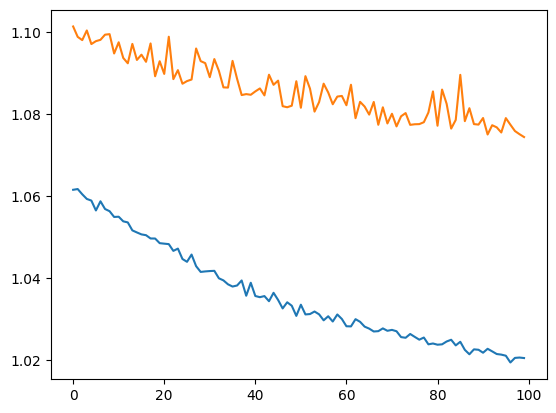

In [82]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.show()

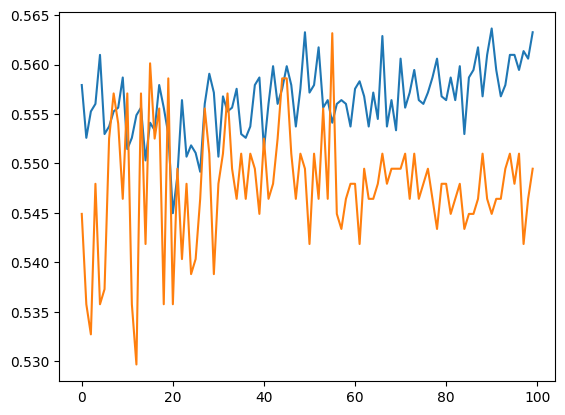

In [85]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.show()

In [65]:
y_pred = model.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [66]:
y_pred_classes = np.argmax(y_pred,axis=1)

In [67]:
y_true = np.argmax(y_test,axis=1)

In [68]:
y_true

array([7, 8, 8, ..., 5, 7, 5], shape=(1617,))

In [71]:
from sklearn.metrics import accuracy_score,classification_report
acc = accuracy_score(y_true,y_pred_classes)
print(acc)

0.5411255411255411


In [75]:
clr = classification_report(y_true,y_pred_classes)
print(clr)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         7
           4       0.33      0.09      0.14        46
           5       0.59      0.55      0.57       472
           6       0.53      0.72      0.61       731
           7       0.50      0.28      0.36       304
           8       0.00      0.00      0.00        57

    accuracy                           0.54      1617
   macro avg       0.33      0.27      0.28      1617
weighted avg       0.51      0.54      0.51      1617



c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

In [86]:
# Hyperparameters
INPUT_DIM = X_train.shape[1]
HIDDEN_LAYER_1 = 64
HIDDEN_LAYER_2 = 32
OUTPUT_CLASSES = y_train.shape[1]

ACTIVATION_HIDDEN = 'relu'
ACTIVATION_OUTPUT = 'softmax'

LEARNING_RATE = 0.001
BATCH_SIZE = 50
EPOCHS = 100
OPTIMIZER = 'adam'
LOSS_FUNCTION = 'categorical_crossentropy'

In [ ]:
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(Dense(HIDDEN_LAYER_1, activation=ACTIVATION_HIDDEN, input_shape=(INPUT_DIM,)))
model.add(Dense(HIDDEN_LAYER_2, activation=ACTIVATION_HIDDEN))
model.add(Dense(OUTPUT_CLASSES, activation=ACTIVATION_OUTPUT))

optimizer = Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss=LOSS_FUNCTION,
    metrics=['accuracy']
)

hist = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    verbose=1
)


Epoch 1/100


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3834 - loss: 1.9687 - val_accuracy: 0.4642 - val_loss: 1.5127
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4428 - loss: 1.3589 - val_accuracy: 0.4703 - val_loss: 1.2725
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4592 - loss: 1.2717 - val_accuracy: 0.4825 - val_loss: 1.2289
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4825 - loss: 1.2319 - val_accuracy: 0.5145 - val_loss: 1.1968
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4950 - loss: 1.2020 - val_accuracy: 0.5068 - val_loss: 1.1789
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5053 - loss: 1.1814 - val_accuracy: 0.5358 - val_loss: 1.1593
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5099 - loss: 1.1667 - val_accuracy: 0.5236 - val_loss: 1.1519
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5194 - loss: 1.1540 - val_accuracy: 0.5297 - val_loss: 1.1

In [88]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred,axis=1)
y_true = np.argmax(y_test,axis=1)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [89]:
acc = accuracy_score(y_true,y_pred_classes)
print(acc)
clr = classification_report(y_true,y_pred_classes)
print(clr)

0.549165120593692
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         7
           4       0.33      0.07      0.11        46
           5       0.57      0.67      0.61       472
           6       0.56      0.64      0.60       731
           7       0.49      0.34      0.40       304
           8       0.00      0.00      0.00        57

    accuracy                           0.55      1617
   macro avg       0.32      0.28      0.29      1617
weighted avg       0.52      0.55      0.53      1617



c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

In [90]:

def build_model(neurons=32, learning_rate=0.001):
    model = Sequential()
    model.add(Dense(neurons, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(neurons//2, activation='relu'))
    model.add(Dense(y_train.shape[1], activation='softmax'))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
from scikeras.wrappers import KerasClassifier

model = KerasClassifier(
    build_fn=build_model,
    neurons=32,            
    learning_rate=0.001,   
    epochs=50,
    batch_size=32,
    verbose=0
)

In [98]:
param_grid = {
    'neurons': [32, 64, 128],
    'learning_rate': [0.001, 0.0005],
    'batch_size': [32, 50],
    'epochs': [50, 100]
}


In [97]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=1
)

grid_result = grid.fit(X_train, y_train)


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\sit

In [100]:
print("Best Accuracy:", grid_result.best_score_)
print("Best Parameters:", grid_result.best_params_)


Best Accuracy: 0.5620211829419167
Best Parameters: {'batch_size': 50, 'epochs': 100, 'learning_rate': 0.0005, 'neurons': 128}


In [101]:
param_dist = {
    'neurons': [32, 64, 128],
    'learning_rate': [0.001, 0.0005, 0.0001],
    'batch_size': [32, 50],
    'epochs': [50, 100]
}


In [102]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=5,            
    cv=3,
    scoring='accuracy',
    n_jobs=1,
    random_state=42
)

random_result = random_search.fit(X_train, y_train)


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\sit

In [103]:
print("Random Search Best Accuracy:", random_result.best_score_)
print("Random Search Best Params:", random_result.best_params_)


Random Search Best Accuracy: 0.5562331450541449
Random Search Best Params: {'neurons': 64, 'learning_rate': 0.0005, 'epochs': 100, 'batch_size': 32}


In [104]:
print("Grid Search Best Accuracy:", grid_result.best_score_)
print("Grid Search Best Params:", grid_result.best_params_)

print("Random Search Best Accuracy:", random_result.best_score_)
print("Random Search Best Params:", random_result.best_params_)


Grid Search Best Accuracy: 0.5620211829419167
Grid Search Best Params: {'batch_size': 50, 'epochs': 100, 'learning_rate': 0.0005, 'neurons': 128}
Random Search Best Accuracy: 0.5562331450541449
Random Search Best Params: {'neurons': 64, 'learning_rate': 0.0005, 'epochs': 100, 'batch_size': 32}


## Summary

In this lab, we worked on predicting the quality of wine using an Artificial Neural Network (ANN). The main goal was to understand the dataset and then improve the model’s performance using hyperparameter tuning techniques.

First, we **loaded the Wine Quality dataset** into a Pandas DataFrame using scikit-learn. After loading the data, we checked the first few rows, the size of the dataset, and the column information. This helped us understand what kind of data we were working with and made sure there were no missing values.

Next, we did **basic data exploration**. We used summary statistics like mean, median, and standard deviation to understand how the values of different features were spread. We also looked at how different features were related to wine quality, which gave us an idea of which factors might affect the quality more.

After that, we moved to **data preprocessing**. The dataset was separated into input features and the target (wine quality). Since neural networks work better when data is scaled, we applied feature scaling using StandardScaler. Then, the data was split into training and testing sets so that we could test the model on unseen data.

Once the data was ready, we built a **basic ANN model** using `MLPClassifier`. This model was trained with default settings to see how well it performed initially. The accuracy of this model was recorded as a baseline.

To improve the results, we applied **hyperparameter tuning** using Grid Search and Random Search. Different values for parameters like hidden layers, activation functions, learning rate, and number of iterations were tested. Cross-validation was used to make sure the results were reliable.

Finally, the **best model after tuning** was evaluated on the test data. The tuned model performed better than the initial one, showing that choosing the right hyperparameters can significantly improve model performance. Overall, this lab helped us understand the complete process of building, training, and optimizing a neural network model.

